In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import functions_spin_p as fy
from importlib import reload

reload(fy)

<module 'functions_spin_p' from '/mnt/c/Users/frnkl/Desktop/thesis_spin_caloritronics/tesis_models/T_model/functions_spin_p.py'>

In [10]:
#Parameters

energy_axis = np.arange(-10, 10 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 0.5 #meV
#gamma = 30
print("The width is:",gamma,"meV")

#Site energies:
e_1 = -0.5 #meV
e_2 = 0.5 #meV

print("The site (spin independent) energies are:", \
      e_1," meV and",e_2," meV")

Energy axis is [-10.    -9.99  -9.98 ...   9.98   9.99  10.  ] meV
The width is: 0.5 meV
The site (spin independent) energies are: -0.5  meV and 0.5  meV


In [11]:
delta = 0 #meV

e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
#v = 0.5*gamma 
v=3

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

print(Hamiltonian)

[[-0.5+0.j  0. +0.j  3. +0.j  0. +0.j]
 [ 0. +0.j -0.5+0.j  0. +0.j  3. +0.j]
 [ 3. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [ 0. +0.j  3. +0.j  0. +0.j  0.5+0.j]]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:79: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


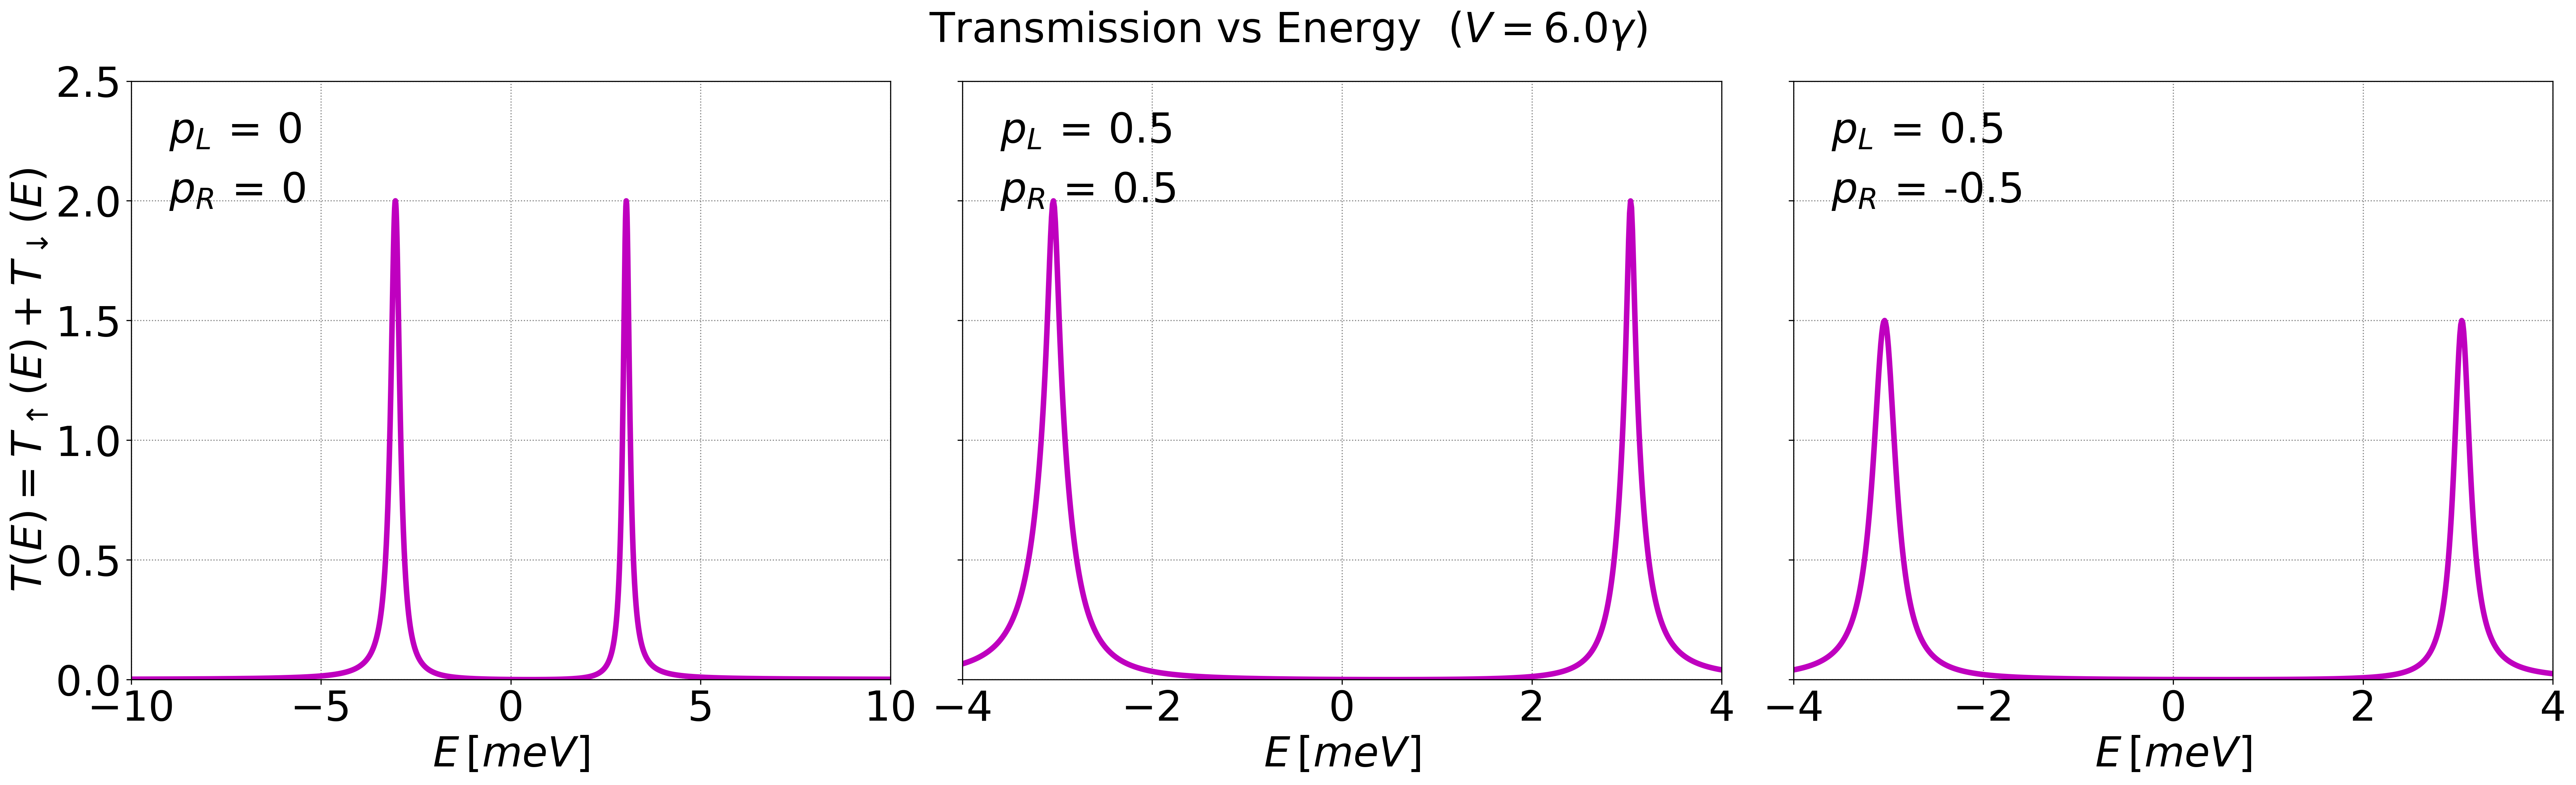

In [12]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(26,8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", lw=4)
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)

p= 0.5

ax2.grid(linestyle=':', color='grey')
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", lw=4)
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)

k=0.5
p_L= k
p_R = -k

ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "m", lw=4)
ax3.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax3.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
ax3.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L), transform=ax3.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)
ax3.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=30,
        verticalalignment='top', bbox=props)



# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax2.set_ylim(0, 2.5)   
ax3.set_ylim(0, 2.5) 
ax1.set_xlim(-10, 10)  
ax2.set_xlim(-4, 4)   
ax3.set_xlim(-4, 4) 

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)
ax3.tick_params(axis='x', labelsize=30)
ax3.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax2.set_yticklabels([])
ax3.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($V=$"+str((v/gamma))+r"$\gamma$)", fontsize=30)
plt.tight_layout()
plt.show()
#fig.savefig('T_Transmission_polarization.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:108: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


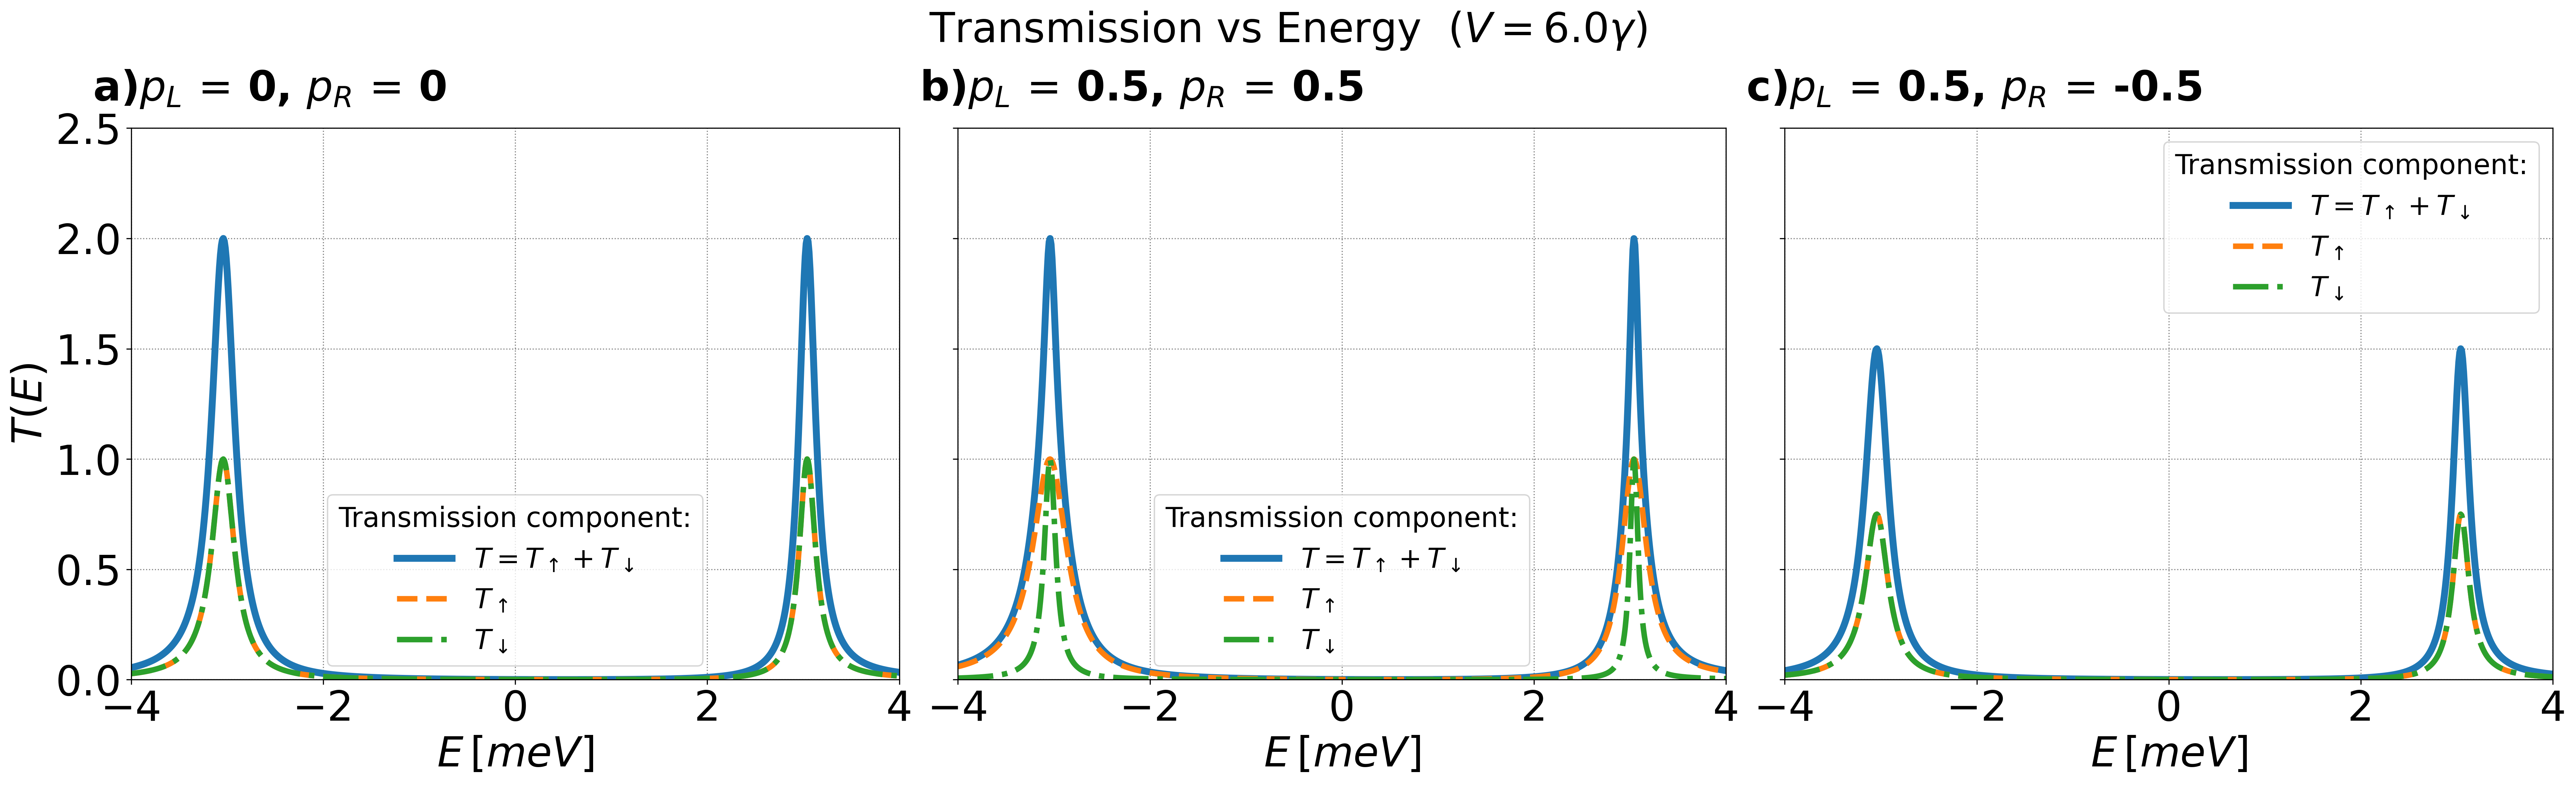

In [13]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(26,8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

ax1.grid(linestyle=':', color='grey')
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#1f77b4", lw=5, label=r"$T=T_{\uparrow}+T_{\downarrow}$")
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0], "#ff7f0e", lw=4, linestyle="--", label=r"$T_{\uparrow}$")
ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#2ca02c", lw=4, linestyle="-.", label=r"$T_{\downarrow}$")
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E)$',fontsize=30)
# ax1.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# ax1.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# Etiqueta a)
ax1.text(-0.05, 1.05, r'a)'+r"$p_{L}\,=\,$"+str(p)+r", $p_{R}\,=\,$"+str(p), transform=ax1.transAxes, fontsize=30, fontweight='bold')
ax1.legend(
    fontsize=20,
    title="Transmission component:",
    title_fontsize=20
)

# t1=fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
#      +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1]

p= 0.5
ax2.grid(linestyle=':', color='grey')
#ax2.plot(energy_axis, t1, "b", lw=4)
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#1f77b4", lw=5, label=r"$T=T_{\uparrow}+T_{\downarrow}$")
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0], "#ff7f0e", lw=4, linestyle="--", label=r"$T_{\uparrow}$")
ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "#2ca02c", lw=4, linestyle="-.", label=r"$T_{\downarrow}$")
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
# ax2.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# ax2.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# Etiqueta b)
ax2.text(-0.05, 1.05, r'b)'+r"$p_{L}\,=\,$"+str(p)+r", $p_{R}\,=\,$"+str(p), transform=ax2.transAxes, fontsize=30, fontweight='bold')
ax2.legend(
    fontsize=20,
    title="Transmission component:",
    title_fontsize=20
)

k=0.5
p_L= k
p_R = -k

ax3.grid(linestyle=':', color='grey')
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "#1f77b4", lw=5, label=r"$T=T_{\uparrow}+T_{\downarrow}$")
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[0], "#ff7f0e", lw=4, linestyle="--", label=r"$T_{\uparrow}$")
ax3.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p_L, p_R)[1], "#2ca02c", lw=4, linestyle="-.", label=r"$T_{\downarrow}$")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax3.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=18)
# ax3.text(0.05, 0.95, r"$p_{L}\,=\,$"+str(p_L), transform=ax3.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# ax3.text(0.05, 0.85, r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=30,
#         verticalalignment='top', bbox=props)
# Etiqueta c)
ax3.text(-0.05, 1.05, r'c)'+r"$p_{L}\,=\,$"+str(p_L)+r", $p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=30, fontweight='bold')
ax3.legend(
    fontsize=20,
    title="Transmission component:",
    title_fontsize=20
)


# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax2.set_ylim(0, 2.5)   
ax3.set_ylim(0, 2.5) 
ax1.set_xlim(-4, 4)  
ax2.set_xlim(-4, 4)   
ax3.set_xlim(-4, 4) 

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)
ax3.tick_params(axis='x', labelsize=30)
ax3.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax2.set_yticklabels([])
ax3.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($V=$"+str(v/gamma)+r"$\gamma$)", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('T_Transmission_polarization_v2.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:67: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


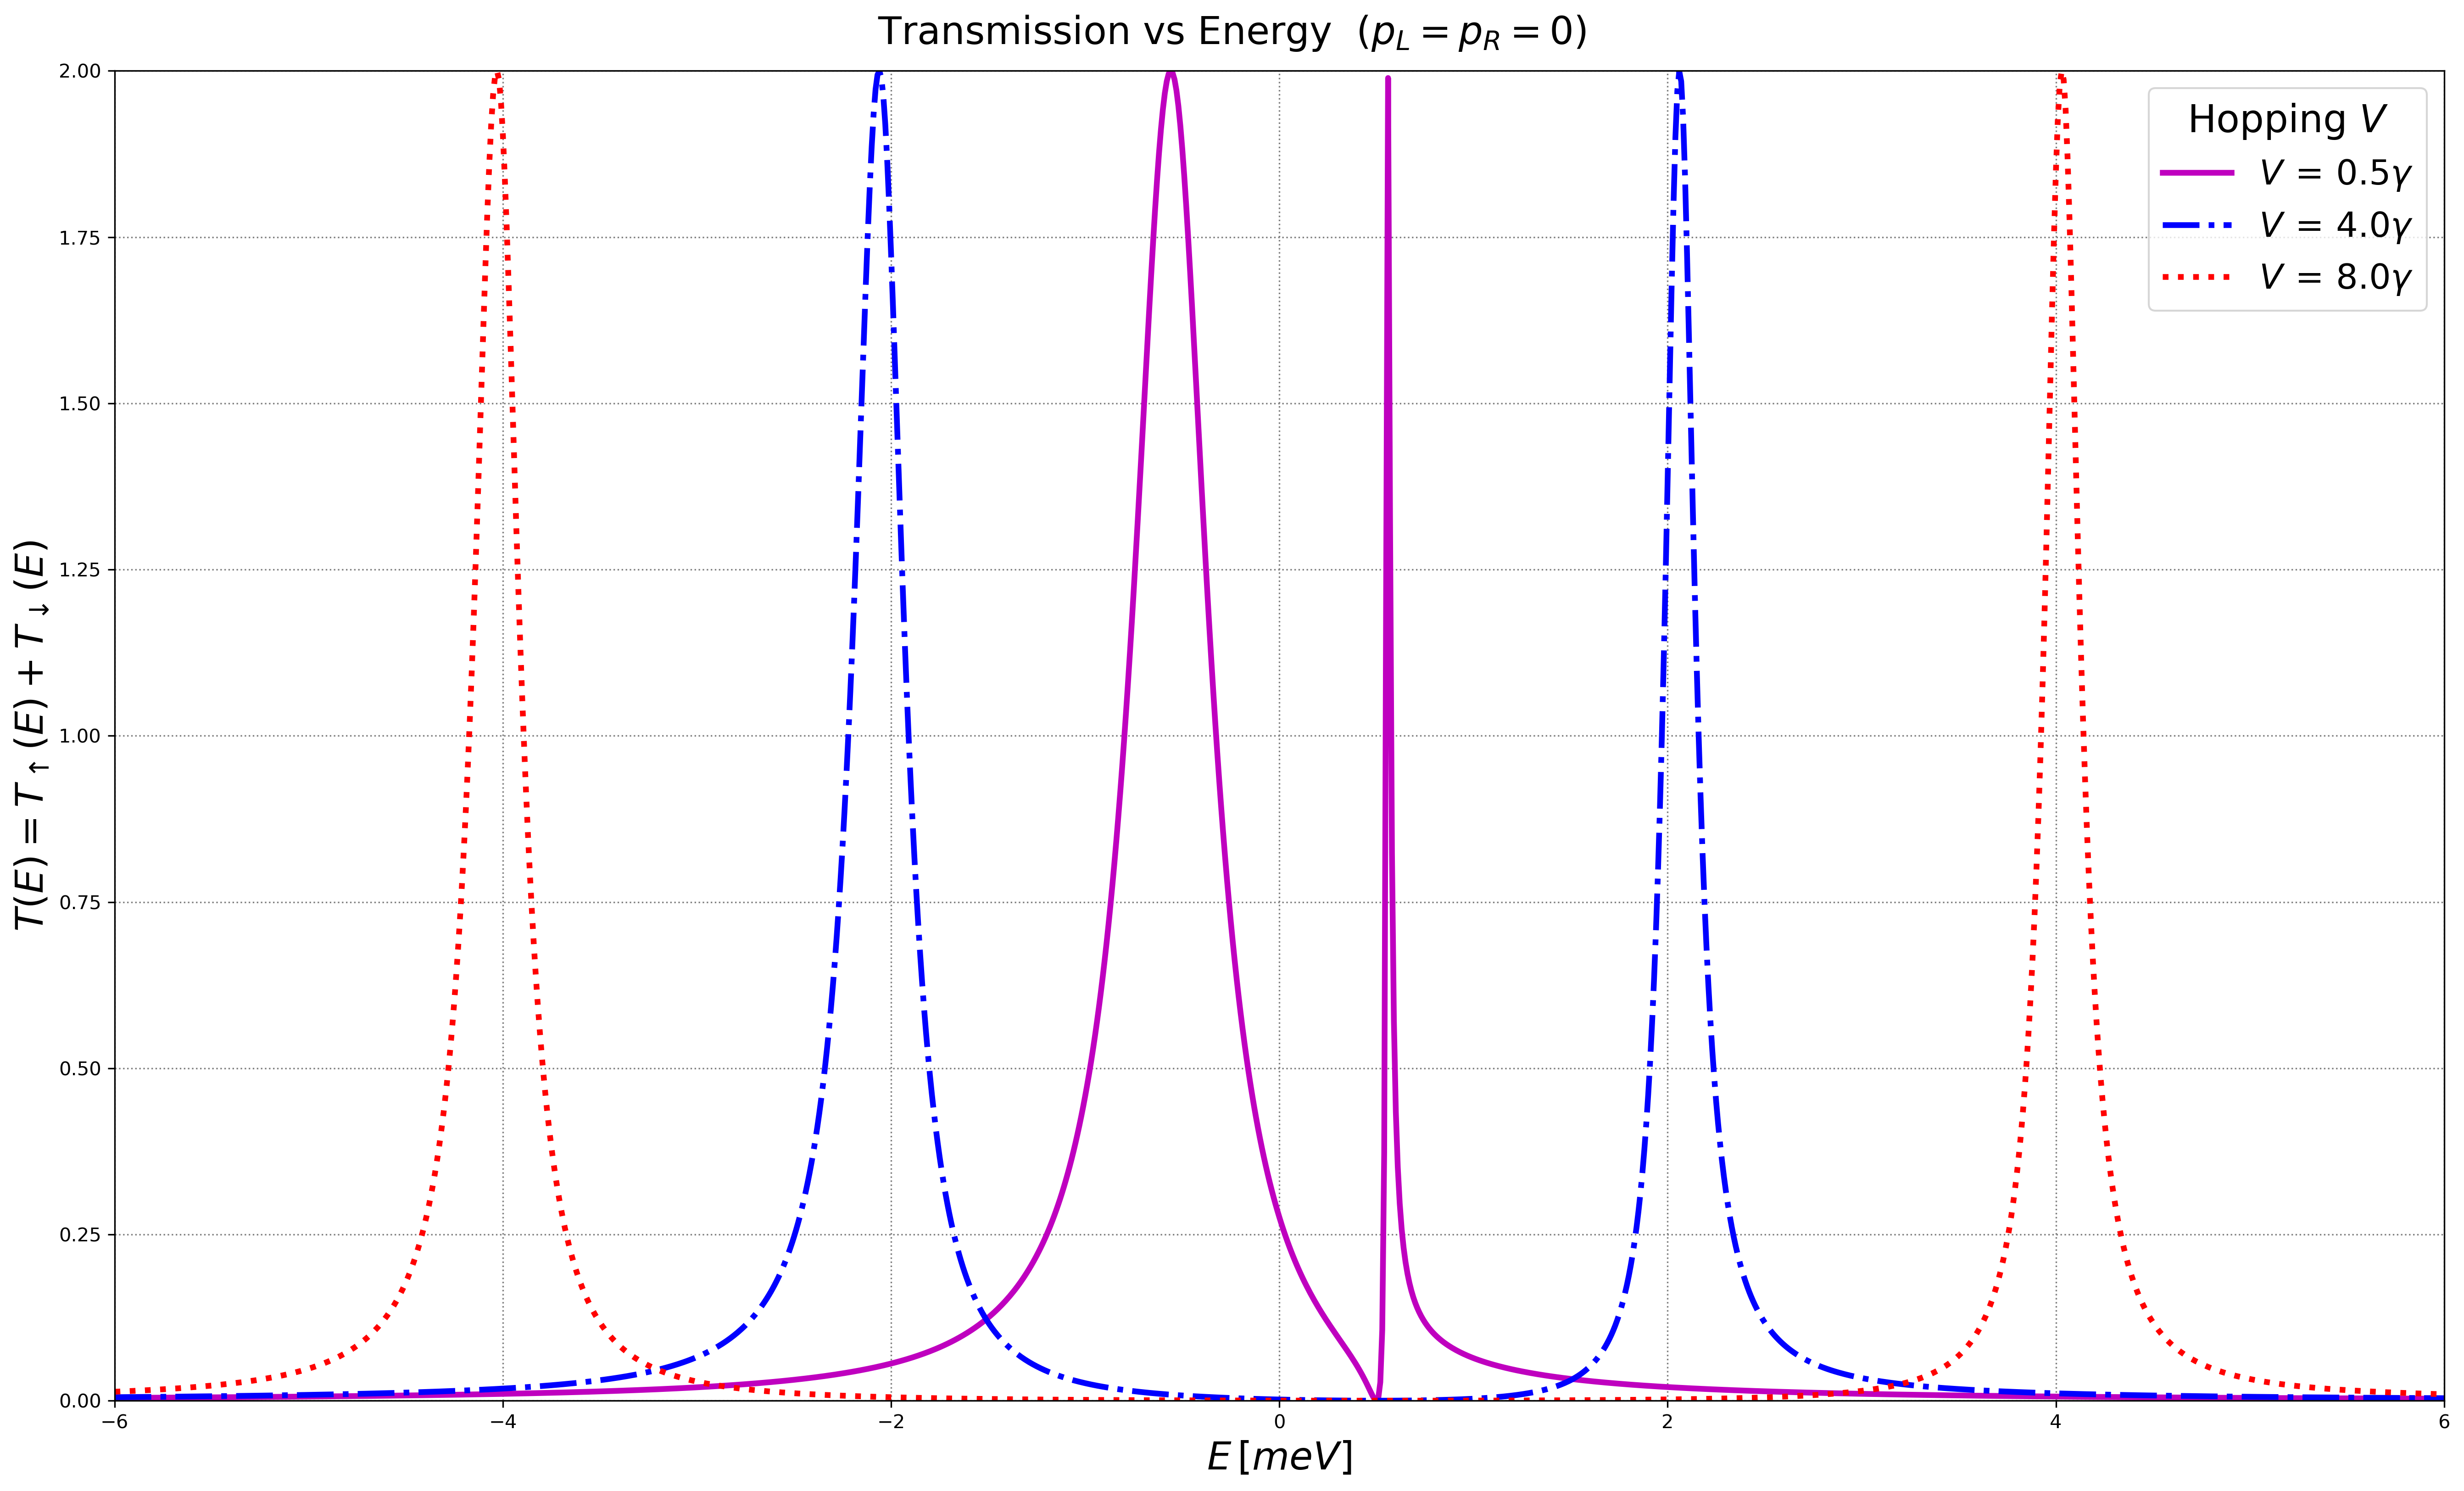

In [14]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(18,11), dpi=300)

#Set the grid for the subplots
gs = GridSpec(1, 1, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 0.5*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=3)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=3)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 8*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle=":", lw=3)

############################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=20)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=20)
ax1.legend(
    fontsize=18,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax1.set_xlim(-6, 6)  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=20)
plt.tight_layout()
plt.show()
#fig.savefig('T_Transmission_reference.jpg')

/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:143: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


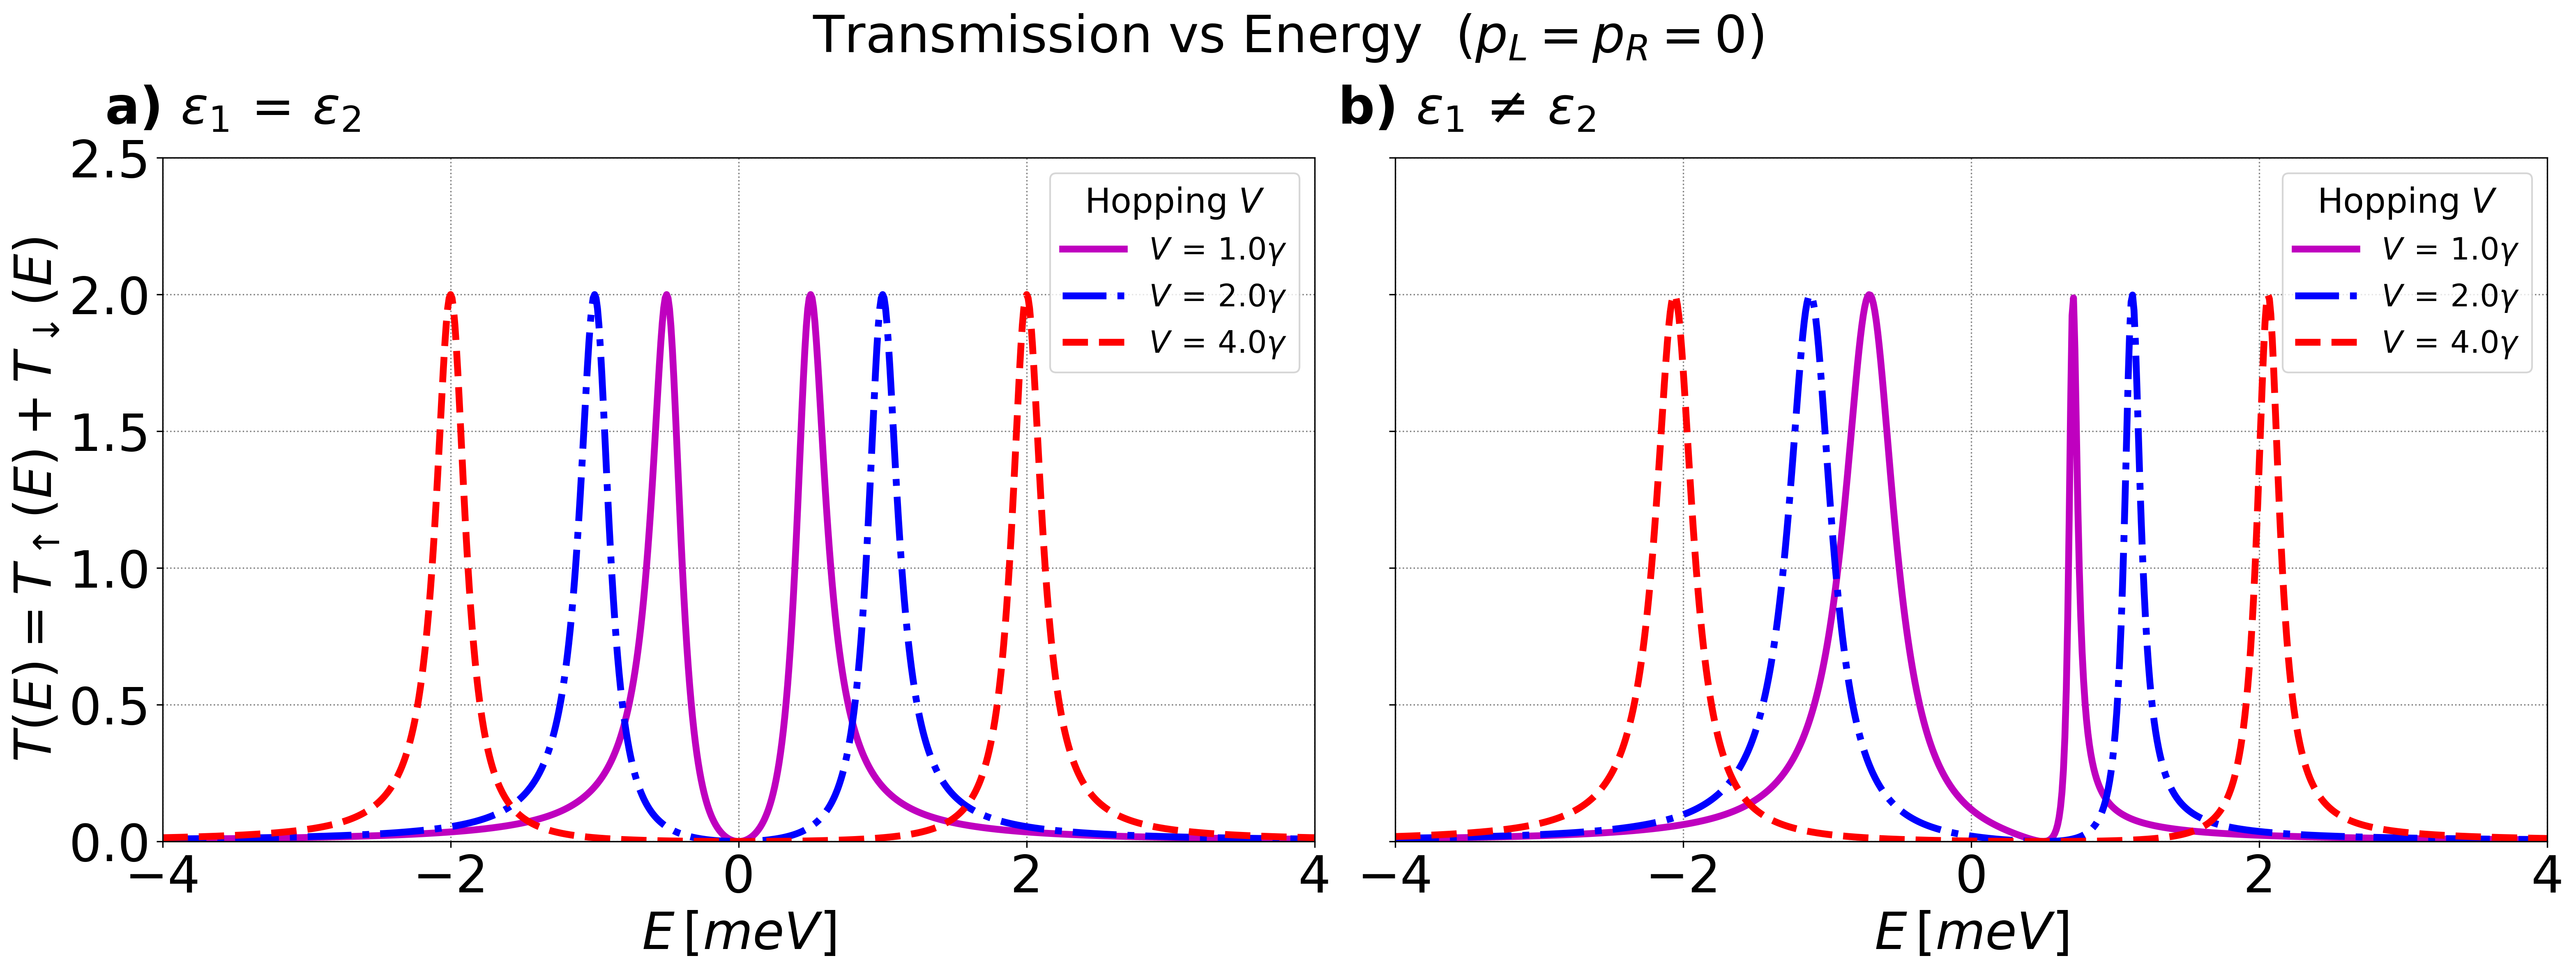

In [15]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(21, 8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 2, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="--", lw=4)

############################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax1.legend(
    fontsize=18,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Etiqueta a)
ax1.text(-0.05, 1.05, r'a) $\epsilon_{1}\,=\,\epsilon_{2}$', transform=ax1.transAxes, fontsize=30, fontweight='bold')

#Site energies:
e_1 = -0.5 #meV
e_2 = 0.5 #meV

ax2.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="--", lw=4)

############################################################################################################################
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax2.legend(
    fontsize=18,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Etiqueta b)
ax2.text(-0.05, 1.05, r'b) $\epsilon_{1}\,\neq\,\epsilon_{2}$', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax1.set_xlim(-4, 4)  
ax2.set_ylim(0, 2.5)  
ax2.set_xlim(-4, 4)

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax2.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('T_Transmission_reference.jpg')


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:143: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


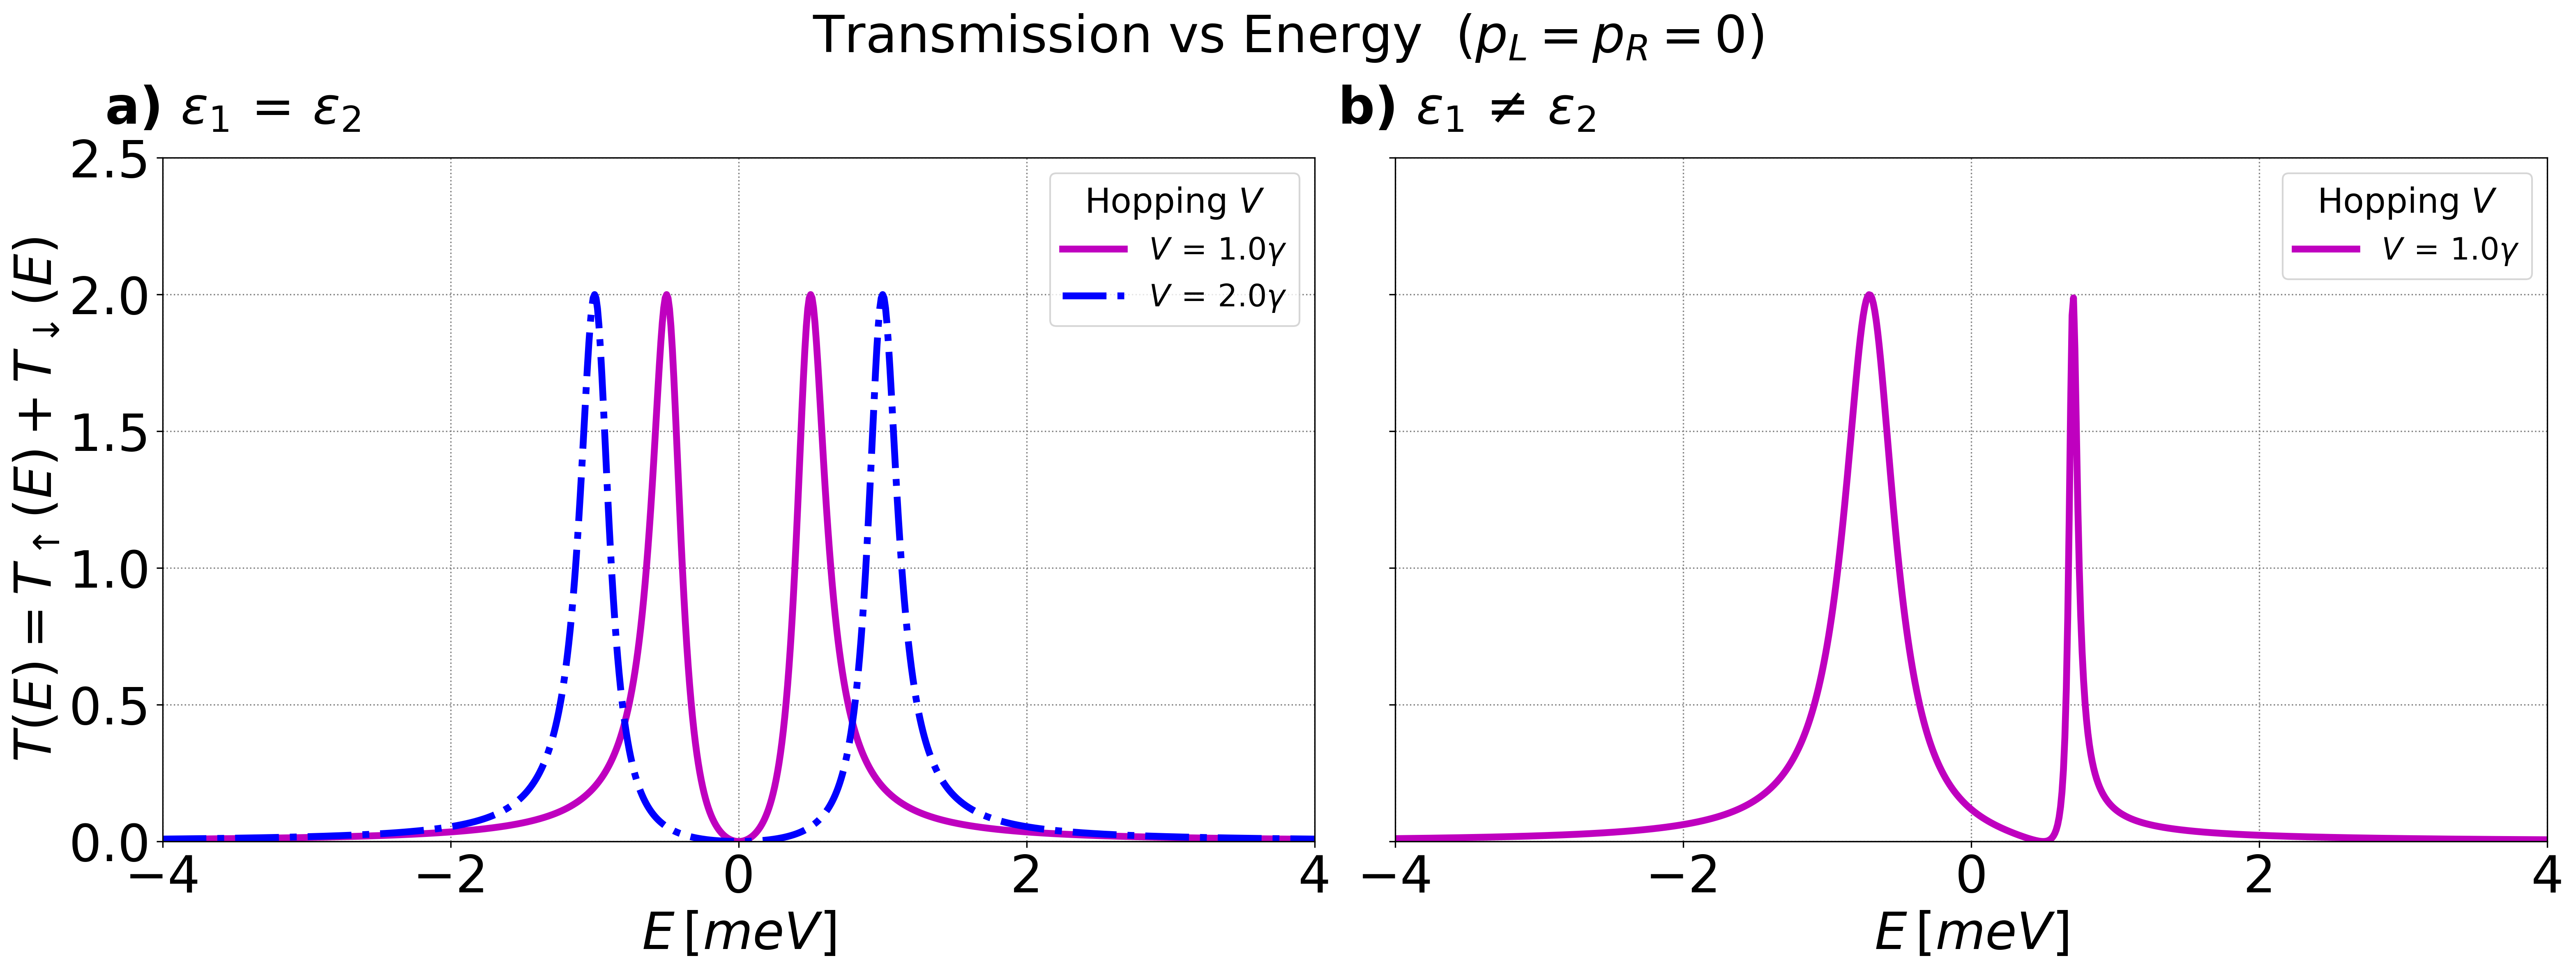

In [18]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(21, 8), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0)

#Set the grid for the subplots
gs = GridSpec(1, 2, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

#POLARIZATION = 0
# Transmission spin up Plot
p=0

#Site energies:
e_1 = 0 #meV
e_2 = 0 #meV

ax1.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

#ax1.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
#     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="--", lw=4)

############################################################################################################################
ax1.set_xlabel(r'$E\,[meV]$',fontsize=30)
ax1.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax1.legend(
    fontsize=18,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Etiqueta a)
ax1.text(-0.05, 1.05, r'a) $\epsilon_{1}\,=\,\epsilon_{2}$', transform=ax1.transAxes, fontsize=30, fontweight='bold')

#Site energies:
e_1 = -0.5 #meV
e_2 = 0.5 #meV

ax2.grid(linestyle=':', color='grey')
################################################################################################################
delta=0
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 1*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
     +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "m", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-", lw=4)

##################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 2*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

#ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
 #    +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "b", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="-.", lw=4)

#####################################################################################################################
e_1_u = e_1 + delta #meV
e_1_d = e_1 - delta #meV
e_2_u = e_2 + delta #meV
e_2_d = e_2 - delta #meV
v = 4*gamma 

Hamiltonian = np.array([[e_1_u, 0 , v , 0],[0, e_1_d, 0, v], [v, 0, e_2_u, 0], [0, v, 0, e_2_d]], dtype = complex)

#ax2.plot(energy_axis, fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[0]\
 #    +fy.Transmission(energy_axis, gamma, Hamiltonian, p, p)[1], "r", label=r"$V\,=\,$"+str(v/gamma)+r"$\gamma$", linestyle="--", lw=4)

############################################################################################################################
ax2.set_xlabel(r'$E\,[meV]$',fontsize=30)
#ax2.set_ylabel(r'$T(E) = T_{\uparrow}(E)+T_{\downarrow}(E)$',fontsize=30)
ax2.legend(
    fontsize=18,
    title="Hopping "+r"$V$",
    title_fontsize=20
)

# Etiqueta b)
ax2.text(-0.05, 1.05, r'b) $\epsilon_{1}\,\neq\,\epsilon_{2}$', transform=ax2.transAxes, fontsize=30, fontweight='bold')

# Stablish limits for the subplots
ax1.set_ylim(0, 2.5)  
ax1.set_xlim(-4, 4)  
ax2.set_ylim(0, 2.5)  
ax2.set_xlim(-4, 4)

# Set the fontsize for the x and y ticks
ax1.tick_params(axis='x', labelsize=30)
ax1.tick_params(axis='y', labelsize=30)
ax2.tick_params(axis='x', labelsize=30)
ax2.tick_params(axis='y', labelsize=30)

# Eliminar los números del eje x en el primer subplot
ax2.set_yticklabels([])

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Transmission vs Energy "+r" ($p_{L}=p_{R}=$"+str(p)+")", fontsize=30)
plt.tight_layout()
plt.show()
fig.savefig('T_Transmission_reference_presentation.jpg')
